In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/aesthetic-ai"

DATA_DIR = f"{BASE_DIR}/data"
RAW_DIR = f"{DATA_DIR}/raw"
PROCESSED_DIR = f"{DATA_DIR}/processed"
LABEL_DIR = f"{DATA_DIR}/labels"
CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints"
RESULT_DIR = f"{BASE_DIR}/results"

for path in [RAW_DIR, PROCESSED_DIR, LABEL_DIR, CHECKPOINT_DIR, RESULT_DIR]:
    os.makedirs(path, exist_ok=True)

print("Drive project folders created.")
print("BASE_DIR:", BASE_DIR)

Drive project folders created.
BASE_DIR: /content/drive/MyDrive/aesthetic-ai


In [ ]:
%cd /content

!rm -rf aesthetic-ai
!git clone https://github.com/dPdms21/aesthetic-ai.git

%cd /content/aesthetic-ai

In [ ]:
!ls

In [ ]:
!pip install -r requirements.txt

In [ ]:
import torch

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Kaggle 연결

In [5]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle token configured.")

Kaggle token configured.


In [6]:
!kaggle datasets list -s aesthetic

ref                                                                title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
nicolacarrassi/ava-aesthetic-visual-assessment                     AVA- Aesthetic Visual Analysis                      33267215727  2023-05-24 20:07:42.793000          14897         21  0.88235295       
taeefnajib/used-car-price-prediction-dataset                       Used Car Price Prediction Dataset                        112006  2023-09-15 12:58:57.503000          29146        207  1                
prathameshbhalekar/aesthetic-visual-analysis-for-satellite-images  Aesthetic Visual Analysis for Satellite Images       6259574039  2023-01-04 09:26:46.127000             68          9

In [7]:
!kaggle datasets list -s "aesthetic visual analysis"

ref                                                                title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
nicolacarrassi/ava-aesthetic-visual-assessment                     AVA- Aesthetic Visual Analysis                      33267215727  2023-05-24 20:07:42.793000          14897         21  0.88235295       
prathameshbhalekar/aesthetic-visual-analysis-for-satellite-images  Aesthetic Visual Analysis for Satellite Images       6259574039  2023-01-04 09:26:46.127000             68          9  0.75             
kanchana1990/colombo-cafes-ratings-and-insights-dataset            Colombo Cafes 🍵: Ratings & Insights Dataset               11961  2024-02-14 17:44:02                   931         57

In [8]:
!kaggle datasets files nicolacarrassi/ava-aesthetic-visual-assessment

Next Page Token = CfDJ8KXhJwB4GRRPqJWFH0ywOemv6C5-YLqew3jMHz08Em6kgLgYgh7x4d41-zN64rEaN7ni6raWRxWwojiBd5dmOWBkcoShe_T0WRlBQHDEqyEtVY6aFoUHL5Q_P3Ox7qbJYtuczTxnOdE
name                          size  creationDate                
------------------------  --------  --------------------------  
AVA_Files/AVA.txt         12493564  2023-05-24 20:14:22.444000  
AVA_Files/README.txt          3868  2023-05-24 20:14:22.114000  
AVA_Files/challenges.txt     26978  2023-05-24 20:14:22.063000  
AVA_Files/tags.txt             949  2023-05-24 20:14:22.097000  
ground_truth_dataset.csv  47876011  2023-05-24 20:14:23.328000  
images/1000.jpg             122187  2023-05-24 20:14:22.398000  
images/10000.jpg             56198  2023-05-24 20:14:22.381000  
images/10002.jpg            117458  2023-05-24 20:14:22.404000  
images/10003.jpg            151623  2023-05-24 20:14:22.479000  
images/10005.jpg             80161  2023-05-24 20:14:22.450000  
images/100050.jpg           133302  2023-05-24 20:14:22.52

In [9]:
RAW_DIR = "/content/drive/MyDrive/aesthetic-ai/data/raw"

!kaggle datasets download \
  -d nicolacarrassi/ava-aesthetic-visual-assessment \
  -f ground_truth_dataset.csv \
  -p {RAW_DIR}

Dataset URL: https://www.kaggle.com/datasets/nicolacarrassi/ava-aesthetic-visual-assessment
License(s): unknown
100% 9.76M/9.76M [00:00<00:00, 22.2MB/s]



In [10]:
import zipfile
import os

RAW_DIR = "/content/drive/MyDrive/aesthetic-ai/data/raw"

zip_path = f"{RAW_DIR}/ground_truth_dataset.csv.zip"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(RAW_DIR)
    print("Extracted:", zip_path)
else:
    print("Zip file not found. Check downloaded files.")

Extracted: /content/drive/MyDrive/aesthetic-ai/data/raw/ground_truth_dataset.csv.zip


In [11]:
!ls -lh /content/drive/MyDrive/aesthetic-ai/data/raw

total 56M
-rw------- 1 root root  46M May 19 15:24 ground_truth_dataset.csv
-rw------- 1 root root 9.8M May 24  2023 ground_truth_dataset.csv.zip


In [12]:
import pandas as pd

csv_path = "/content/drive/MyDrive/aesthetic-ai/data/raw/ground_truth_dataset.csv"

df = pd.read_csv(csv_path)

print(df.shape)
print(df.columns)
df.head()

(255508, 11)
Index(['image_num', 'vote_1', 'vote_2', 'vote_3', 'vote_4', 'vote_5', 'vote_6',
       'vote_7', 'vote_8', 'vote_9', 'vote_10'],
      dtype='object')


,image_num,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10
0,953417,0.0,0.000000,0.000000,0.040323,0.258065,0.403226,0.185484,0.080645,0.024194,0.008065
1,953777,0.0,0.023438,0.015625,0.023438,0.101562,0.312500,0.273438,0.164062,0.062500,0.023438
2,953756,0.0,0.015625,0.023438,0.070312,0.273438,0.390625,0.156250,0.039062,0.015625,0.015625
3,954195,0.0,0.008197,0.057377,0.213115,0.459016,0.188525,0.049180,0.008197,0.000000,0.016393
4,953903,0.0,0.008065,0.032258,0.040323,0.266129,0.403226,0.137097,0.072581,0.024194,0.016129


In [13]:
import pandas as pd

csv_path = "/content/drive/MyDrive/aesthetic-ai/data/raw/ground_truth_dataset.csv"
df = pd.read_csv(csv_path)

vote_cols = [f"vote_{i}" for i in range(1, 11)]

df["score"] = sum(df[f"vote_{i}"] * i for i in range(1, 11))
df["label"] = (df["score"] >= 5.0).astype(int)
df["image_name"] = df["image_num"].astype(str) + ".jpg"

labels_df = df[["image_name", "score", "label"]]

print(labels_df.shape)
labels_df.head()

(255508, 3)


,image_name,score,label
0,953417.jpg,6.112903,1
1,953777.jpg,6.593750,1
2,953756.jpg,5.796875,1
3,954195.jpg,5.040984,1
4,953903.jpg,5.943548,1


In [18]:
labels_df["score"].describe()

,score
count,255508.000000
mean,5.383302
std,0.731300
min,1.808989
25%,4.911215
50%,5.386647
75%,5.865627
max,8.600000


In [17]:
print(labels_df["label"].value_counts())
print(labels_df["label"].value_counts(normalize=True))

label
1    180880
0     74628
Name: count, dtype: int64
label
1    0.707923
0    0.292077
Name: proportion, dtype: float64


In [19]:
import os

LABEL_DIR = "/content/drive/MyDrive/aesthetic-ai/data/labels"
os.makedirs(LABEL_DIR, exist_ok=True)

label_path = f"{LABEL_DIR}/labels.csv"
labels_df.to_csv(label_path, index=False)

print("Saved:", label_path)

Saved: /content/drive/MyDrive/aesthetic-ai/data/labels/labels.csv


In [20]:
!ls -lh /content/drive/MyDrive/aesthetic-ai/data/labels

total 7.5M
-rw------- 1 root root 7.5M May 19 15:30 labels.csv


In [21]:
low_df = labels_df[labels_df["score"] < 4.5].copy()
high_df = labels_df[labels_df["score"] >= 6.0].copy()

print("low:", len(low_df))
print("high:", len(high_df))

low: 27726
high: 49710


In [22]:
sample_low = low_df.sample(n=500, random_state=42)
sample_high = high_df.sample(n=500, random_state=42)

sample_df = pd.concat([sample_low, sample_high], ignore_index=True)
sample_df = sample_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(sample_df.shape)
print(sample_df["label"].value_counts())
sample_df.head()

(1000, 3)
label
1    500
0    500
Name: count, dtype: int64


,image_name,score,label
0,580943.jpg,6.639053,1
1,545401.jpg,6.420382,1
2,521405.jpg,6.481481,1
3,463536.jpg,6.546448,1
4,22452.jpg,4.472477,0


In [23]:
sample_label_path = f"{LABEL_DIR}/sample_labels.csv"

sample_df.to_csv(sample_label_path, index=False)

print("Saved:", sample_label_path)

Saved: /content/drive/MyDrive/aesthetic-ai/data/labels/sample_labels.csv


In [24]:
!ls -lh /content/drive/MyDrive/aesthetic-ai/data/labels

total 7.5M
-rw------- 1 root root 7.5M May 19 15:30 labels.csv
-rw------- 1 root root  30K May 19 15:32 sample_labels.csv


In [25]:
import os

SAMPLE_IMAGE_DIR = "/content/drive/MyDrive/aesthetic-ai/data/processed/sample_images"
os.makedirs(SAMPLE_IMAGE_DIR, exist_ok=True)

print("Sample image dir:", SAMPLE_IMAGE_DIR)

Sample image dir: /content/drive/MyDrive/aesthetic-ai/data/processed/sample_images


AVA 원본 zip 다운

In [1]:
import os

LOCAL_RAW_DIR = "/content/ava_dataset"
os.makedirs(LOCAL_RAW_DIR, exist_ok=True)

!kaggle datasets download \
  -d nicolacarrassi/ava-aesthetic-visual-assessment \
  -p /content/ava_dataset

Dataset URL: https://www.kaggle.com/datasets/nicolacarrassi/ava-aesthetic-visual-assessment
License(s): unknown
100% 31.0G/31.0G [06:01<00:00, 91.9MB/s]



In [2]:
!ls -lh /content/ava_dataset
!df -h /content

total 31G
-rw-r--r-- 1 root root 31G May 24  2023 ava-aesthetic-visual-assessment.zip
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   74G   39G  66% /


zip 중 1000개 추출

In [12]:
import os
import zipfile
import pandas as pd
from tqdm import tqdm

zip_path = "/content/ava_dataset/ava-aesthetic-visual-assessment.zip"

sample_label_path = "/content/drive/MyDrive/aesthetic-ai/data/labels/sample_labels.csv"
sample_df = pd.read_csv(sample_label_path)

SAMPLE_IMAGE_DIR = "/content/drive/MyDrive/aesthetic-ai/data/processed/sample_images"
os.makedirs(SAMPLE_IMAGE_DIR, exist_ok=True)

wanted_files = set("images/" + sample_df["image_name"].astype(str))

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_names = set(zip_ref.namelist())

    extracted = 0
    missing = []

    for file_path in tqdm(wanted_files):
        if file_path in zip_names:
            zip_ref.extract(file_path, SAMPLE_IMAGE_DIR)
            extracted += 1
        else:
            missing.append(file_path)

print("Extracted:", extracted)
print("Missing:", len(missing))

100%|██████████| 1000/1000 [00:12<00:00, 80.28it/s]

Extracted: 1000
Missing: 0


In [13]:
import glob

image_files = glob.glob("/content/drive/MyDrive/aesthetic-ai/data/processed/sample_images/images/*.jpg")
print("Downloaded sample images:", len(image_files))

Downloaded sample images: 1000


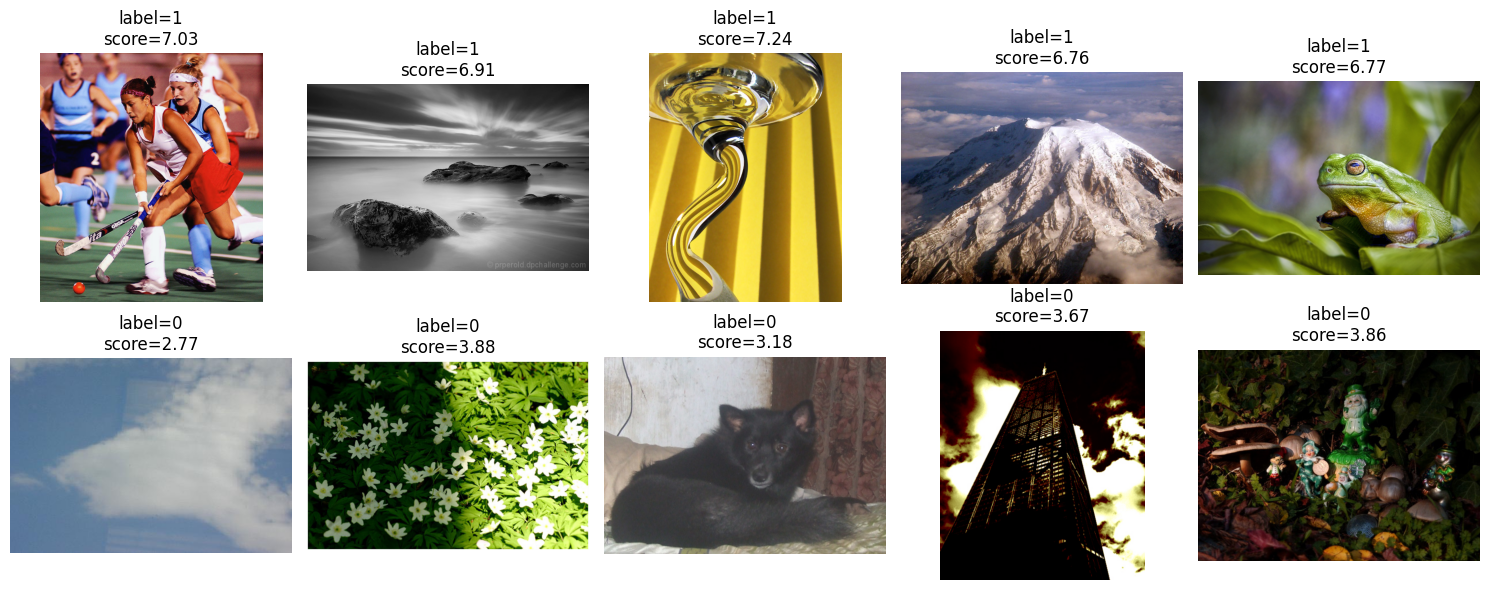

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

LABEL_PATH = "/content/drive/MyDrive/aesthetic-ai/data/labels/sample_labels.csv"
IMAGE_DIR = "/content/drive/MyDrive/aesthetic-ai/data/processed/sample_images/images"

sample_df = pd.read_csv(LABEL_PATH)

# high 5장, low 5장 확인
check_df = pd.concat([
    sample_df[sample_df["label"] == 1].sample(5, random_state=1),
    sample_df[sample_df["label"] == 0].sample(5, random_state=1)
]).reset_index(drop=True)

plt.figure(figsize=(15, 6))

for i, row in check_df.iterrows():
    image_path = os.path.join(IMAGE_DIR, row["image_name"])
    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f'label={row["label"]}\nscore={row["score"]:.2f}')

plt.tight_layout()
plt.show()

추출 이미지 마음에 안 들어서 값 조정

In [7]:
import pandas as pd

LABEL_DIR = "/content/drive/MyDrive/aesthetic-ai/data/labels"
label_path = f"{LABEL_DIR}/labels.csv"

labels_df = pd.read_csv(label_path)

print(labels_df.shape)
labels_df.head()

(255508, 3)


,image_name,score,label
0,953417.jpg,6.112903,1
1,953777.jpg,6.593750,1
2,953756.jpg,5.796875,1
3,954195.jpg,5.040984,1
4,953903.jpg,5.943548,1


In [8]:
strict_low_df = labels_df[labels_df["score"] <= 4.0].copy()
strict_high_df = labels_df[labels_df["score"] >= 6.5].copy()

print("strict low:", len(strict_low_df))
print("strict high:", len(strict_high_df))

strict low: 8088
strict high: 15597


In [9]:
sample_low = strict_low_df.sample(n=500, random_state=42)
sample_high = strict_high_df.sample(n=500, random_state=42)

sample_df = pd.concat([sample_low, sample_high], ignore_index=True)
sample_df = sample_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(sample_df.shape)
print(sample_df["label"].value_counts())
sample_df.head()

(1000, 3)
label
1    500
0    500
Name: count, dtype: int64


,image_name,score,label
0,426266.jpg,6.671096,1
1,941927.jpg,6.713043,1
2,684528.jpg,7.343590,1
3,40673.jpg,6.736842,1
4,301024.jpg,3.321782,0


In [10]:
sample_label_path = f"{LABEL_DIR}/sample_labels.csv"
sample_df.to_csv(sample_label_path, index=False)

print("Saved:", sample_label_path)

Saved: /content/drive/MyDrive/aesthetic-ai/data/labels/sample_labels.csv


In [11]:
!rm -rf /content/drive/MyDrive/aesthetic-ai/data/processed/sample_images

AVA zip 삭제

In [15]:
!rm -rf /content/ava_dataset
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   44G   70G  39% /


train / validation split 만들기

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

LABEL_DIR = "/content/drive/MyDrive/aesthetic-ai/data/labels"

sample_label_path = f"{LABEL_DIR}/sample_labels.csv"
sample_df = pd.read_csv(sample_label_path)

train_df, val_df = train_test_split(
    sample_df,
    test_size=0.2,
    random_state=42,
    stratify=sample_df["label"]
)

train_path = f"{LABEL_DIR}/train_labels.csv"
val_path = f"{LABEL_DIR}/val_labels.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)

print("train:", train_df.shape)
print(train_df["label"].value_counts())

print("val:", val_df.shape)
print(val_df["label"].value_counts())

print("Saved:", train_path)
print("Saved:", val_path)

train: (800, 3)
label
1    400
0    400
Name: count, dtype: int64
val: (200, 3)
label
1    100
0    100
Name: count, dtype: int64
Saved: /content/drive/MyDrive/aesthetic-ai/data/labels/train_labels.csv
Saved: /content/drive/MyDrive/aesthetic-ai/data/labels/val_labels.csv


train/validation 데이터 경로 및 이미지 개수 확인

In [17]:
import os
import glob
import pandas as pd

TRAIN_LABEL_PATH = "/content/drive/MyDrive/aesthetic-ai/data/labels/train_labels.csv"
VAL_LABEL_PATH = "/content/drive/MyDrive/aesthetic-ai/data/labels/val_labels.csv"
IMAGE_DIR = "/content/drive/MyDrive/aesthetic-ai/data/processed/sample_images/images"

train_df = pd.read_csv(TRAIN_LABEL_PATH)
val_df = pd.read_csv(VAL_LABEL_PATH)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("images:", len(glob.glob(f"{IMAGE_DIR}/*.jpg")))

train_df.head()

train: (800, 3)
val: (200, 3)
images: 1000


,image_name,score,label
0,668988.jpg,7.203488,1
1,396614.jpg,3.517045,0
2,467623.jpg,6.814159,1
3,151662.jpg,3.754386,0
4,633906.jpg,6.880851,1


PyTorch Dataset 및 DataLoader 생성

In [18]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class AestheticDataset(Dataset):
    def __init__(self, label_df, image_dir, transform=None):
        self.df = label_df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = os.path.join(self.image_dir, row["image_name"])
        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = AestheticDataset(train_df, IMAGE_DIR, train_transform)
val_dataset = AestheticDataset(val_df, IMAGE_DIR, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 25
val batches: 7


ImageNet 사전학습 ResNet18 모델 구성

In [19]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(model.fc)

device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Linear(in_features=512, out_features=2, bias=True)


학습 및 검증 함수 정의

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    acc = correct / total

    return avg_loss, acc


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    acc = correct / total

    return avg_loss, acc

5 epoch baseline 학습 실행

In [21]:
NUM_EPOCHS = 5

history = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/5] train_loss=0.4945, train_acc=0.7438, val_loss=0.4775, val_acc=0.7850


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/5] train_loss=0.1618, train_acc=0.9500, val_loss=0.3423, val_acc=0.8600


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [3/5] train_loss=0.0756, train_acc=0.9762, val_loss=0.4316, val_acc=0.8600


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [4/5] train_loss=0.0374, train_acc=0.9900, val_loss=0.3556, val_acc=0.8500


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [5/5] train_loss=0.0374, train_acc=0.9888, val_loss=0.3524, val_acc=0.8850


ResNet18 baseline 학습 결과, 최종 validation accuracy는 0.885로 나타났다. train accuracy가 validation accuracy보다 높아 소규모 샘플 데이터에 대한 과적합 가능성을 확인했다.

ResNet18 feature extraction 모델 구성

In [22]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

weights = models.ResNet18_Weights.IMAGENET1K_V1
feature_model = models.resnet18(weights=weights)

# backbone 고정
for param in feature_model.parameters():
    param.requires_grad = False

# 마지막 분류층만 학습
in_features = feature_model.fc.in_features
feature_model.fc = nn.Linear(in_features, 2)

feature_model = feature_model.to(device)

feature_criterion = nn.CrossEntropyLoss()
feature_optimizer = torch.optim.Adam(
    feature_model.fc.parameters(),
    lr=1e-4
)

print(feature_model.fc)

device: cuda
Linear(in_features=512, out_features=2, bias=True)


feature extraction 5 epoch 학습 실행

In [23]:
NUM_EPOCHS = 5

feature_history = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        feature_model, train_loader, feature_criterion, feature_optimizer, device
    )

    val_loss, val_acc = evaluate(
        feature_model, val_loader, feature_criterion, device
    )

    feature_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/5] train_loss=0.7715, train_acc=0.4750, val_loss=0.8363, val_acc=0.4700


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/5] train_loss=0.7359, train_acc=0.4988, val_loss=0.8062, val_acc=0.4900


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [3/5] train_loss=0.7087, train_acc=0.5288, val_loss=0.7690, val_acc=0.5350


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [4/5] train_loss=0.6862, train_acc=0.5713, val_loss=0.7435, val_acc=0.5650


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [5/5] train_loss=0.6673, train_acc=0.5975, val_loss=0.7210, val_acc=0.5850


**ResNet18 feature extraction 실험 결과**

ImageNet 사전학습 ResNet18의 backbone을 고정하고 마지막 fc layer만 학습한 결과, 최종 validation accuracy는 0.585로 나타났다. Full fine-tuning 결과보다 낮아, AVA 미감 분류에서는 전체 모델을 미세조정하는 방식이 더 적합함을 확인했다.

feature extraction 결과 저장

In [24]:
import os
import torch
import pandas as pd

CHECKPOINT_DIR = "/content/drive/MyDrive/aesthetic-ai/checkpoints"
RESULT_DIR = "/content/drive/MyDrive/aesthetic-ai/results"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

feature_model_path = f"{CHECKPOINT_DIR}/resnet18_feature_extraction_sample1000.pth"
feature_history_path = f"{RESULT_DIR}/resnet18_feature_extraction_history.csv"

torch.save(feature_model.state_dict(), feature_model_path)
pd.DataFrame(feature_history).to_csv(feature_history_path, index=False)

print("Saved model:", feature_model_path)
print("Saved history:", feature_history_path)

Saved model: /content/drive/MyDrive/aesthetic-ai/checkpoints/resnet18_feature_extraction_sample1000.pth
Saved history: /content/drive/MyDrive/aesthetic-ai/results/resnet18_feature_extraction_history.csv


fine-tuning 방식별 성능 비교

In [25]:
comparison_df = pd.DataFrame([
    {
        "experiment": "full_fine_tuning",
        "model": "ResNet18",
        "trainable_layers": "all layers",
        "best_val_acc": max([h["val_acc"] for h in history]),
        "final_val_acc": history[-1]["val_acc"]
    },
    {
        "experiment": "feature_extraction",
        "model": "ResNet18",
        "trainable_layers": "fc layer only",
        "best_val_acc": max([h["val_acc"] for h in feature_history]),
        "final_val_acc": feature_history[-1]["val_acc"]
    }
])

comparison_path = "/content/drive/MyDrive/aesthetic-ai/results/fine_tuning_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

comparison_df

,experiment,model,trainable_layers,best_val_acc,final_val_acc
0,full_fine_tuning,ResNet18,all layers,0.885,0.885
1,feature_extraction,ResNet18,fc layer only,0.585,0.585


full fine-tuning 학습 곡선 확인

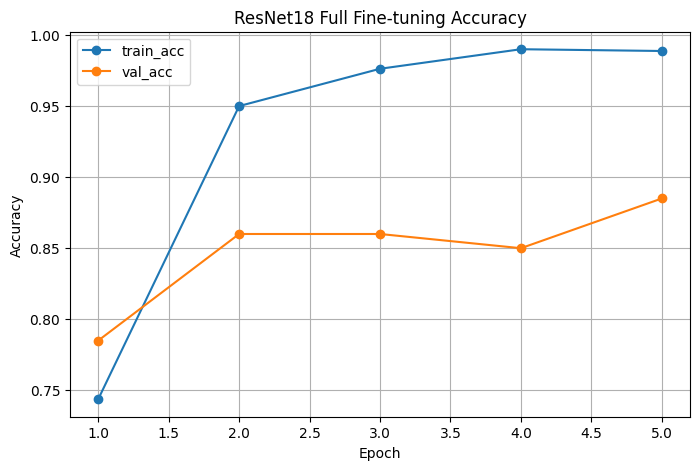

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train_acc")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Full Fine-tuning Accuracy")
plt.legend()
plt.grid(True)
plt.show()

full fine-tuning loss 곡선 확인

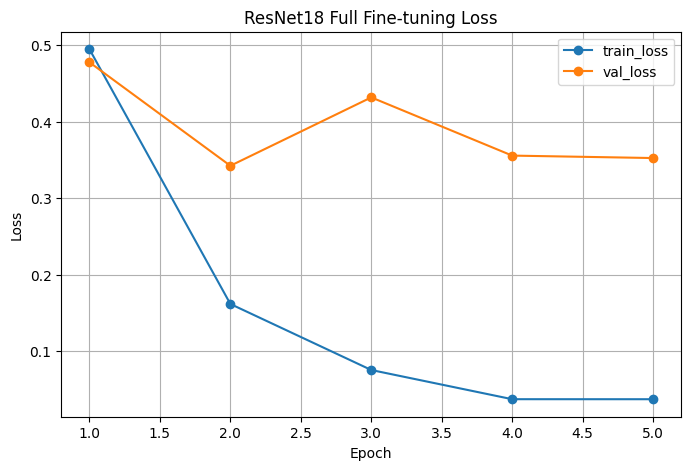

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Full Fine-tuning Loss")
plt.legend()
plt.grid(True)
plt.show()

학습 곡선 확인 결과, train accuracy는 계속 상승했지만 validation accuracy는 2 epoch 이후 정체되어 소규모 샘플 데이터에 대한 과적합 가능성을 확인했다.

validation confusion matrix 확인

Confusion Matrix
[[83 17]
 [ 6 94]]

Classification Report
              precision    recall  f1-score   support

         low       0.93      0.83      0.88       100
        high       0.85      0.94      0.89       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200



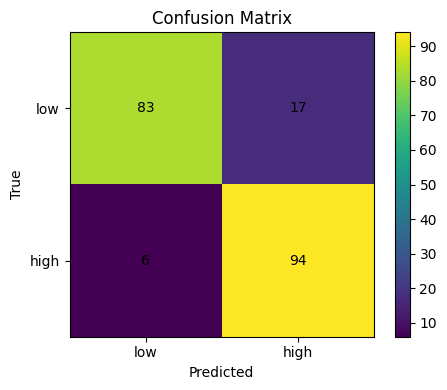

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(all_labels, all_preds, target_names=["low", "high"]))

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

classes = ["low", "high"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

Confusion matrix 확인 결과, validation 200장 중 low 83장, high 94장을 올바르게 예측했다. high 클래스는 94% recall로 잘 분류되었지만, low 이미지 17장을 high로 예측하여 low 클래스 구분에서 상대적으로 더 많은 오류가 발생했다.

validation 예측 성공/실패 샘플 확인

In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

# validation 예측 결과 저장
model.eval()

pred_results = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for label, pred in zip(labels.cpu().numpy(), preds.cpu().numpy()):
            pred_results.append({
                "true_label": label,
                "pred_label": pred
            })

pred_df = val_df.reset_index(drop=True).copy()
pred_df["true_label"] = [r["true_label"] for r in pred_results]
pred_df["pred_label"] = [r["pred_label"] for r in pred_results]
pred_df["is_correct"] = pred_df["true_label"] == pred_df["pred_label"]

print(pred_df["is_correct"].value_counts())
pred_df.head()

is_correct
True     177
False     23
Name: count, dtype: int64


,image_name,score,label,true_label,pred_label,is_correct
0,731759.jpg,6.764706,1,1,1,True
1,210855.jpg,3.958333,0,0,0,True
2,343122.jpg,3.886076,0,0,0,True
3,228267.jpg,3.698305,0,0,0,True
4,664923.jpg,6.880383,1,1,1,True


오분류 이미지 시각화

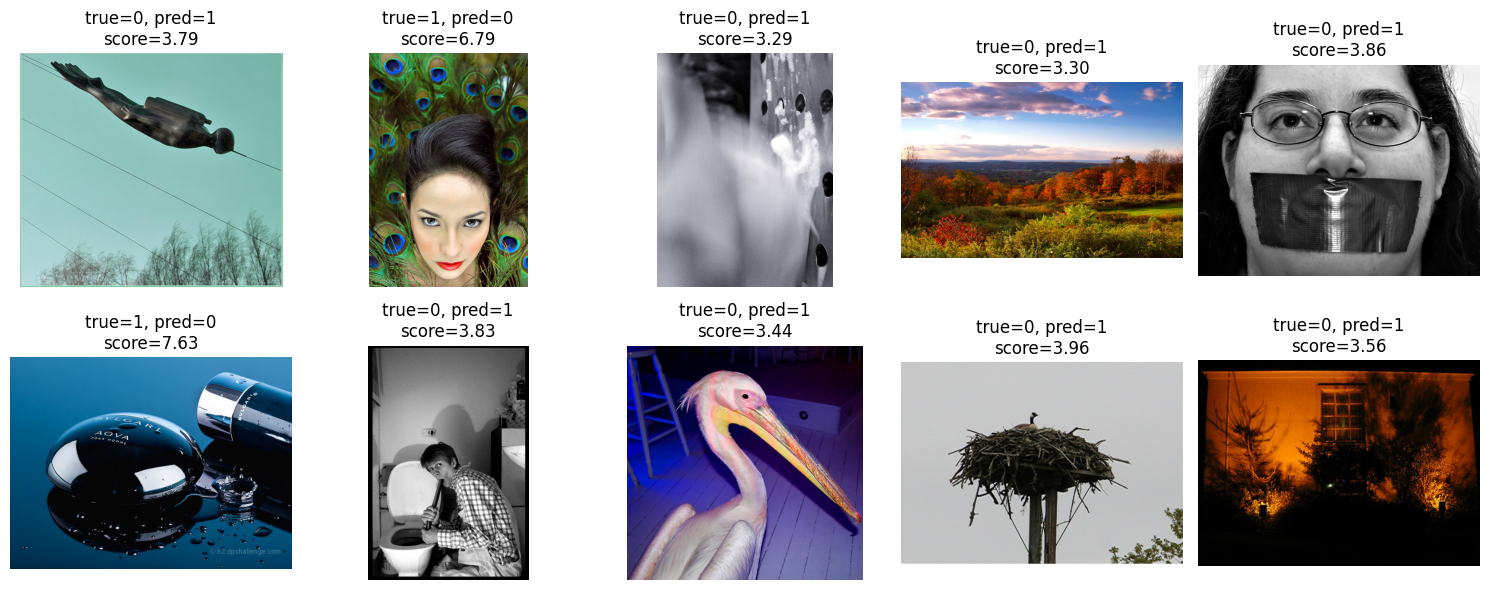

In [30]:
wrong_df = pred_df[pred_df["is_correct"] == False].sample(
    n=min(10, len(pred_df[pred_df["is_correct"] == False])),
    random_state=42
).reset_index(drop=True)

plt.figure(figsize=(15, 6))

for i, row in wrong_df.iterrows():
    image_path = os.path.join(IMAGE_DIR, row["image_name"])
    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f'true={row["true_label"]}, pred={row["pred_label"]}\nscore={row["score"]:.2f}'
    )

plt.tight_layout()
plt.show()

모델 및 학습 이력 저장

In [32]:
import os
import torch
import pandas as pd

CHECKPOINT_DIR = "/content/drive/MyDrive/aesthetic-ai/checkpoints"
RESULT_DIR = "/content/drive/MyDrive/aesthetic-ai/results"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

model_path = f"{CHECKPOINT_DIR}/resnet18_full_finetuning_sample1000.pth"
history_path = f"{RESULT_DIR}/resnet18_full_finetuning_history.csv"

torch.save(model.state_dict(), model_path)
pd.DataFrame(history).to_csv(history_path, index=False)

print("Saved model:", model_path)
print("Saved history:", history_path)

Saved model: /content/drive/MyDrive/aesthetic-ai/checkpoints/resnet18_full_finetuning_sample1000.pth
Saved history: /content/drive/MyDrive/aesthetic-ai/results/resnet18_full_finetuning_history.csv


accuracy/loss 그래프 저장

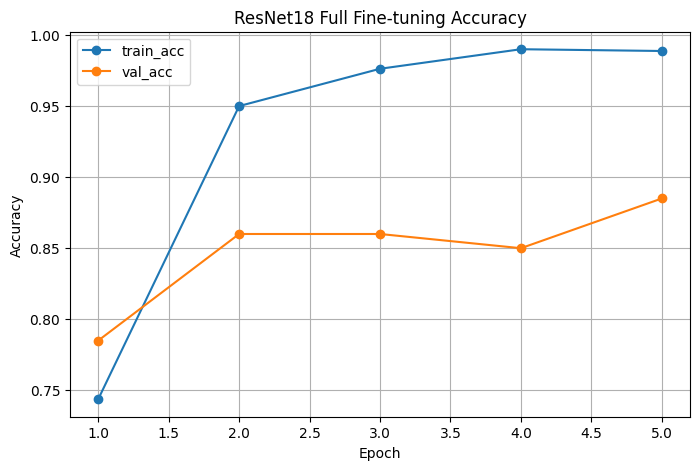

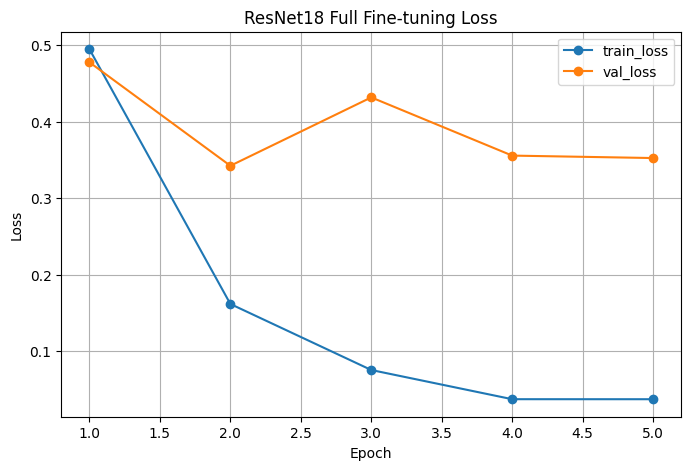

Saved: /content/drive/MyDrive/aesthetic-ai/results/resnet18_full_finetuning_accuracy.png
Saved: /content/drive/MyDrive/aesthetic-ai/results/resnet18_full_finetuning_loss.png


In [33]:
import matplotlib.pyplot as plt
import pandas as pd

history_df = pd.DataFrame(history)

acc_fig_path = f"{RESULT_DIR}/resnet18_full_finetuning_accuracy.png"
loss_fig_path = f"{RESULT_DIR}/resnet18_full_finetuning_loss.png"

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train_acc")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Full Fine-tuning Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(acc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Full Fine-tuning Loss")
plt.legend()
plt.grid(True)
plt.savefig(loss_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", acc_fig_path)
print("Saved:", loss_fig_path)

confusion matrix 결과 저장

In [34]:
cm_path = f"{RESULT_DIR}/resnet18_full_finetuning_confusion_matrix.csv"

cm_df = pd.DataFrame(
    cm,
    index=["true_low", "true_high"],
    columns=["pred_low", "pred_high"]
)

cm_df.to_csv(cm_path)

print("Saved:", cm_path)
cm_df

Saved: /content/drive/MyDrive/aesthetic-ai/results/resnet18_full_finetuning_confusion_matrix.csv


,pred_low,pred_high
true_low,83,17
true_high,6,94


실험 요약 CSV 저장

In [35]:
summary = {
    "experiment": "resnet18_full_finetuning_sample1000",
    "dataset": "AVA sample",
    "train_size": len(train_df),
    "val_size": len(val_df),
    "low_rule": "score <= 4.0",
    "high_rule": "score >= 6.5",
    "model": "ResNet18",
    "pretraining": "ImageNet",
    "training_strategy": "full fine-tuning",
    "epochs": NUM_EPOCHS,
    "best_val_acc": max([h["val_acc"] for h in history]),
    "final_val_acc": history[-1]["val_acc"],
    "note": "Initial baseline experiment using strict high/low AVA samples."
}

summary_df = pd.DataFrame([summary])
summary_path = f"{RESULT_DIR}/resnet18_full_finetuning_summary.csv"

summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
summary_df

Saved: /content/drive/MyDrive/aesthetic-ai/results/resnet18_full_finetuning_summary.csv


,experiment,dataset,train_size,val_size,low_rule,high_rule,model,pretraining,training_strategy,epochs,best_val_acc,final_val_acc,note
0,resnet18_full_finetuning_sample1000,AVA sample,800,200,score <= 4.0,score >= 6.5,ResNet18,ImageNet,full fine-tuning,5,0.885,0.885,Initial baseline experiment using strict high/...


In [36]:
!ls -lh /content/drive/MyDrive/aesthetic-ai/results
!ls -lh /content/drive/MyDrive/aesthetic-ai/checkpoints

total 245K
-rw------- 1 root root  164 May 19 16:11 fine_tuning_comparison.csv
-rw------- 1 root root  308 May 19 16:11 resnet18_feature_extraction_history.csv
-rw------- 1 root root 122K May 19 16:21 resnet18_full_finetuning_accuracy.png
-rw------- 1 root root   50 May 19 16:21 resnet18_full_finetuning_confusion_matrix.csv
-rw------- 1 root root  309 May 19 16:20 resnet18_full_finetuning_history.csv
-rw------- 1 root root 121K May 19 16:21 resnet18_full_finetuning_loss.png
-rw------- 1 root root  326 May 19 16:21 resnet18_full_finetuning_summary.csv
total 86M
-rw------- 1 root root 43M May 19 16:11 resnet18_feature_extraction_sample1000.pth
-rw------- 1 root root 43M May 19 16:20 resnet18_full_finetuning_sample1000.pth
